In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import random

In [ ]:
np.random.seed(0)

In [ ]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)

11490434/11490434 [==============================] - 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)


In [ ]:
assert(X_train.shape[0] == Y_train.shape[0]), "Image and labels not matched"
assert(X_test.shape[0] == Y_test.shape[0]), "Image and labels not matched"
assert(X_train.shape[1:] == (28,28)), "Dimensions of images should be 28X28"
assert(X_test.shape[1:] == (28,28)), "Dimensions of images should be 28X28"

In [ ]:
samples = []

columns = 5
classes = 10
fig, axs = plt.subplots(nrows=classes, ncols=columns, figsize=(5,10))
fig.tight_layout()
for x in range(columns): #
  for y in range(classes): # iterate over each number in the dataset
    X_selected = X_train[Y_train == y] # picks an image with label for y
    axs[y][x].imshow(X_selected[random.randint(0, len(X_selected - 1)), :, :], cmap=plt.get_cmap("gray")) #shows the selected digit, picked randomly, then move on to next row.
    axs[y][x].axis('off')
    if x == 0:
      axs[y][x].set_title(y, y=.15, x=-.5)
      samples.append(len(X_selected))

In [ ]:
print(samples)
plt.figure(figsize=(12,4))
plt.bar(range(0, classes), samples)
plt.title("Training Dataset Size Distribution")
plt.ylabel("Imageset Size")
plt.xlabel("Digits (0-9)")

In [ ]:
Y_train = to_categorical(Y_train, 10)
Y_test = to_categorical(Y_test, 10)


In [ ]:
X_train = X_train/255
X_test = X_test/255

In [ ]:
pixels = 784
X_train = X_train.reshape(X_train.shape[0], pixels)
X_test = X_test.reshape(X_test.shape[0], pixels)

print(X_test.shape)

(10000, 784)


In [ ]:
from re import L
def create_model():
  model = Sequential()
  model.add(Dense(units=10 , input_dim=pixels, activation='relu'))
  model.add(Dense(units=10, activation='relu'))
  model.add(Dense(units=10, activation='softmax'))
  model.compile(Adam(learning_rate=.01), loss='categorical_crossentropy', metrics=['accuracy'])
  return model

In [ ]:
model = create_model()
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                7850      
                                                                 
 dense_1 (Dense)             (None, 10)                110       
                                                                 
 dense_2 (Dense)             (None, 10)                110       
                                                                 
Total params: 8070 (31.52 KB)
Trainable params: 8070 (31.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


In [ ]:
h = model.fit(X_train, Y_train, validation_split=.1, epochs = 10, batch_size = 200, verbose=1, shuffle=1)


Epoch 1/10
270/270 [==============================] - 2s 4ms/step - loss: 0.5528 - accuracy: 0.8242 - val_loss: 0.2657 - val_accuracy: 0.9220
Epoch 2/10
270/270 [==============================] - 1s 3ms/step - loss: 0.2896 - accuracy: 0.9146 - val_loss: 0.2280 - val_accuracy: 0.9355
Epoch 3/10
270/270 [==============================] - 1s 3ms/step - loss: 0.2647 - accuracy: 0.9216 - val_loss: 0.2179 - val_accuracy: 0.9388
Epoch 4/10
270/270 [==============================] - 1s 4ms/step - loss: 0.2553 - accuracy: 0.9238 - val_loss: 0.2267 - val_accuracy: 0.9313
Epoch 5/10
270/270 [==============================] - 1s 5ms/step - loss: 0.2458 - accuracy: 0.9262 - val_loss: 0.2210 - val_accuracy: 0.9347
Epoch 6/10
270/270 [==============================] - 1s 3ms/step - loss: 0.2385 - accuracy: 0.9284 - val_loss: 0.2188 - val_accuracy: 0.9370
Epoch 7/10
270/270 [==============================] - 1s 3ms/step - loss: 0.2294 - accuracy: 0.9310 - val_loss: 0.2082 - val_accuracy: 0.9390
Epoch 

Text(0, 0.5, 'accuracy')

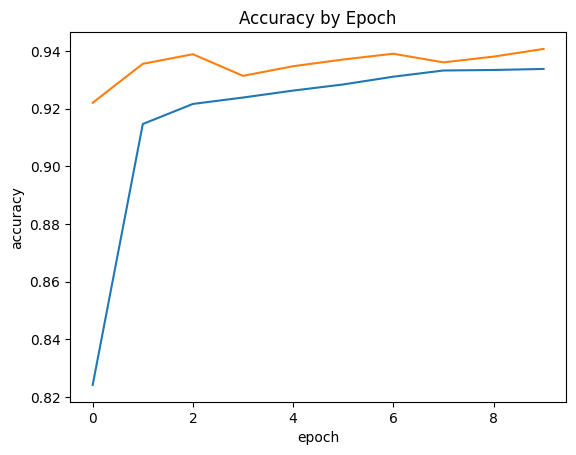

In [ ]:
plt.plot(h.history['accuracy'])
plt.plot(h.history['val_accuracy'])
plt.title('Accuracy by Epoch')
plt.xlabel('epoch')
plt.ylabel('accuracy')

Text(0, 0.5, 'loss')

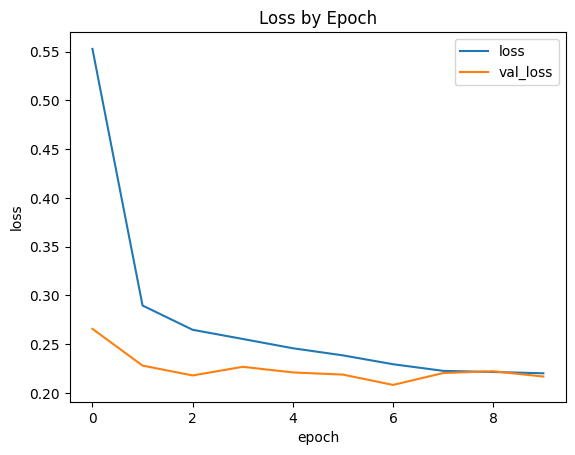

In [ ]:
plt.plot(h.history['loss'])
plt.plot(h.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.title('Loss by Epoch')
plt.xlabel('epoch')
plt.ylabel('loss')

In [ ]:
score = model.evaluate(X_test, Y_test, verbose=1)
print(type(score))
print('Test score:', score[0])
print('Test accuracy:', score[1])

313/313 [==============================] - 1s 1ms/step - loss: 0.2511 - accuracy: 0.9279
<class 'list'>
Test score: 0.25114333629608154
Test accuracy: 0.9279000163078308


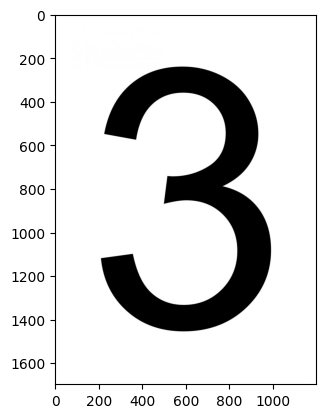

In [ ]:
import requests
from PIL import Image
url = 'https://printables.space/files/uploads/download-and-print/large-printable-numbers/3-a4-1200x1697.jpg'
response = requests.get(url, stream=True)
img = Image.open(response.raw)
plt.imshow(img)

(28, 28, 3)
(28, 28)


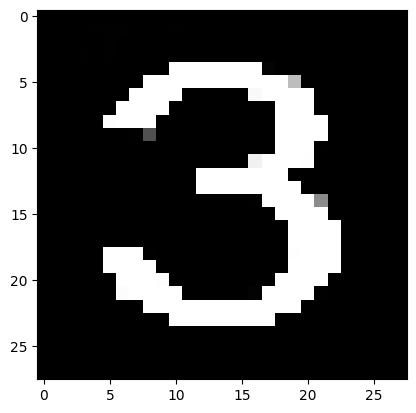

In [ ]:
import cv2

img_arr = np.asarray(img)
resized = cv2.resize(img_arr, (28,28))
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
test_img = cv2.bitwise_not(gray)
print(resized.shape)
print(gray.shape)
plt.imshow(test_img,cmap=plt.get_cmap('gray'))

In [ ]:
test_img = test_img/255
test_img = test_img.reshape(1,784)
print(test_img)

In [ ]:
prediction = model.predict(test_img)
classes = np.argmax(prediction, axis=1) #how to predict classes with sequential after tensorflow 2.6
print("predicted digit: " + str(classes))

1/1 [==============================] - 0s 84ms/step
predicted digit: [3]
